## Importing Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading Dataset
import pandas as pd
df = pd.read_csv(r"personality_dataset.csv")
df


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert
...,...,...,...,...,...,...,...,...
4995,5,No,6,5,No,14,8,Extrovert
4996,7,No,2,3,Yes,2,5,Introvert
4997,2,No,7,3,No,11,3,Extrovert
4998,2,Yes,9,3,No,15,7,Extrovert


# Exploratory Data Analysis

In [3]:
# information about the dataset
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Time_spent_Alone           5000 non-null   int64
 1   Stage_fear                 5000 non-null   str  
 2   Social_event_attendance    5000 non-null   int64
 3   Going_outside              5000 non-null   int64
 4   Drained_after_socializing  5000 non-null   str  
 5   Friends_circle_size        5000 non-null   int64
 6   Post_frequency             5000 non-null   int64
 7   Personality                5000 non-null   str  
dtypes: int64(5), str(3)
memory usage: 312.6 KB


In [4]:
# descriptive statistics of the dataset
df.describe()  

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.969000,4.995200,3.523400,7.253200,4.759800
std,3.033922,2.862449,2.088618,4.045783,2.780369
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,2.000000,5.000000,3.000000
50%,5.000000,5.000000,4.000000,7.000000,5.000000
75%,7.000000,7.000000,5.000000,10.000000,7.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [5]:
# Checking for missing values
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [6]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(128)

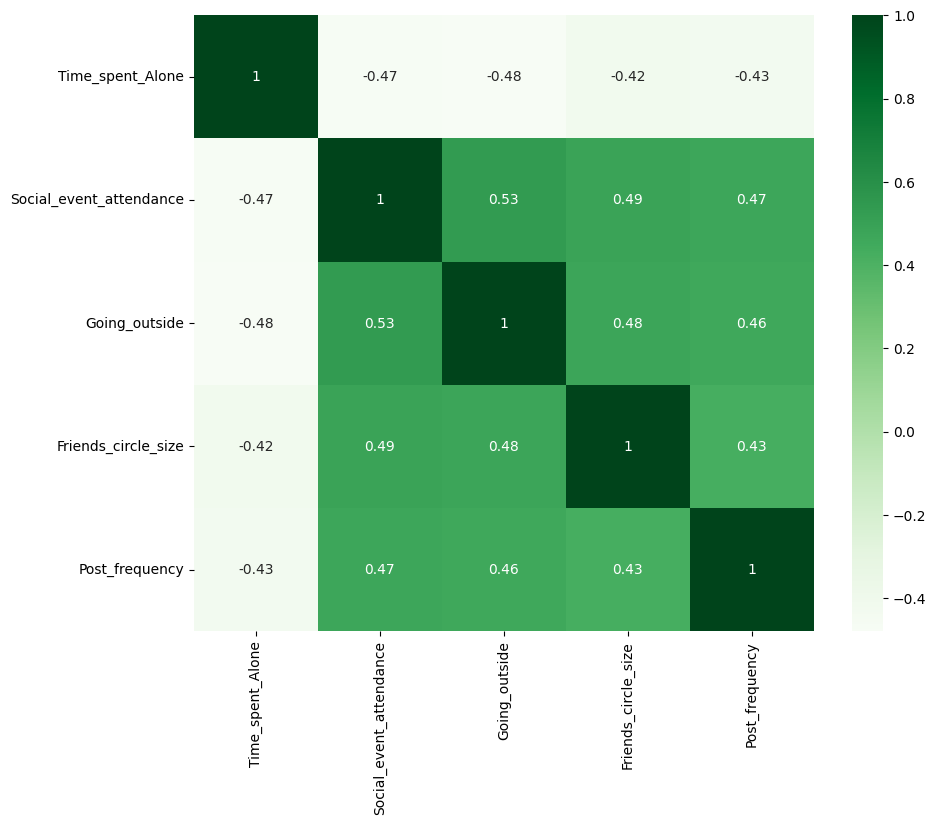

In [7]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='Greens')
plt.show()

<Axes: >

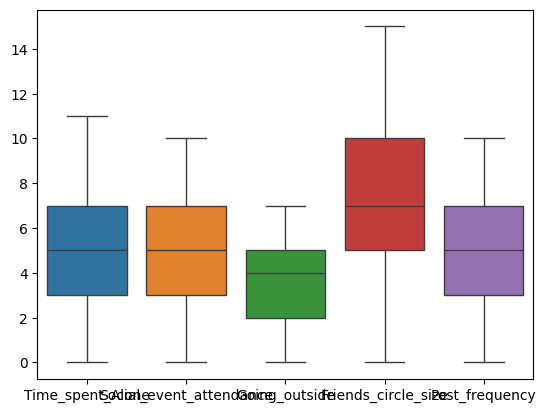

In [8]:
# Checking for outliers
sns.boxplot(df)

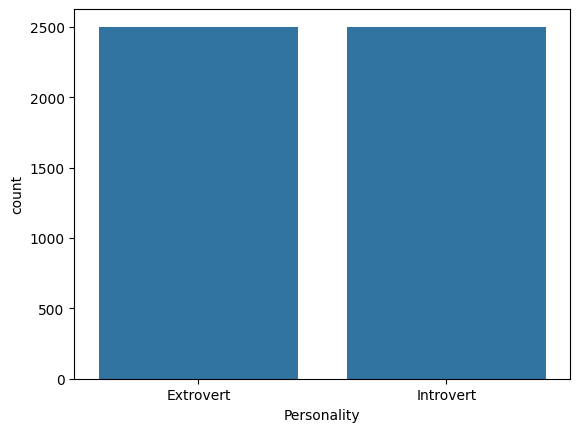

In [9]:
# Personality distribution
sns.countplot(x='Personality', data=df)
plt.show()

# Data Preprocessing

In [10]:
# Removing duplicates
df = df.drop_duplicates()
df.shape

(4872, 8)

#### Encodings

In [11]:
le1 = LabelEncoder()
df["Stage_fear"] =le1.fit_transform(df["Stage_fear"])

In [12]:
le2 = LabelEncoder()
df["Drained_after_socializing"]=le2.fit_transform(df["Drained_after_socializing"])

In [13]:
le3 = LabelEncoder()
df["Personality"]=le3.fit_transform(df["Personality"])

In [14]:
x = df.drop("Personality",axis=1)
y = df["Personality"]

In [15]:
# Splitting the dataset into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Model Building and Metrics

## Logistic Regression

In [16]:
LR = LogisticRegression()
LR.fit(x_train,y_train)
LR_train_pred = LR.predict(x_train)
LR_test_pred = LR.predict(x_test)

In [17]:
print("TRAIN")
print(confusion_matrix(y_train,LR_train_pred))
print(classification_report(y_train,LR_train_pred))
print("TEST")
print(confusion_matrix(y_test,LR_test_pred))
print(classification_report(y_test,LR_test_pred))

TRAIN
[[1887   17]
 [  20 1973]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1904
           1       0.99      0.99      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[520   8]
 [  8 439]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       528
           1       0.98      0.98      0.98       447

    accuracy                           0.98       975
   macro avg       0.98      0.98      0.98       975
weighted avg       0.98      0.98      0.98       975



## Decision Tree

In [18]:
DT = DecisionTreeClassifier()
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(DT, param_grid, cv=5)
grid.fit(x_train, y_train)
# Best parameters
print("Best Parameters:", grid.best_params_)
# Best model
best_model_DT = grid.best_estimator_
DT_train_pred = best_model_DT.predict(x_train)
DT_test_pred = best_model_DT.predict(x_test)

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [19]:
print("TRAIN")
print(confusion_matrix(y_train,DT_train_pred))
print(classification_report(y_train,DT_train_pred))
print("TEST")
print(confusion_matrix(y_test,DT_test_pred))
print(classification_report(y_test,DT_test_pred))

TRAIN
[[1903    1]
 [   8 1985]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1904
           1       1.00      1.00      1.00      1993

    accuracy                           1.00      3897
   macro avg       1.00      1.00      1.00      3897
weighted avg       1.00      1.00      1.00      3897

TEST
[[526   2]
 [  4 443]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       528
           1       1.00      0.99      0.99       447

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



## Random Forest

In [20]:
RF = RandomForestClassifier()
param_grid = {
    'n_estimators': [10, 50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(RF, param_grid, cv=5)
grid.fit(x_train, y_train)
print("Best Parameters:", grid.best_params_)
best_model_RF = grid.best_estimator_
RF_train_pred = best_model_RF.predict(x_train)
RF_test_pred = best_model_RF.predict(x_test)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [21]:
print("TRAIN")
print(confusion_matrix(y_train,RF_train_pred))
print(classification_report(y_train,RF_train_pred))
print("TEST")
print(confusion_matrix(y_test,RF_test_pred))
print(classification_report(y_test,RF_test_pred))

TRAIN
[[1887   17]
 [   4 1989]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1904
           1       0.99      1.00      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[525   3]
 [  1 446]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       528
           1       0.99      1.00      1.00       447

    accuracy                           1.00       975
   macro avg       1.00      1.00      1.00       975
weighted avg       1.00      1.00      1.00       975



## Adaptive Boost

In [22]:
AB = AdaBoostClassifier()
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1, 10]
}
grid = GridSearchCV(AB, param_grid, cv=5)
grid.fit(x_train, y_train)
print("Best Parameters:", grid.best_params_)
best_model_AB = grid.best_estimator_
AB_train_pred = best_model_AB.predict(x_train)
AB_test_pred = best_model_AB.predict(x_test)

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 100}


In [23]:
print("TRAIN")
print(confusion_matrix(y_train,AB_train_pred))
print(classification_report(y_train,AB_train_pred))
print("TEST")
print(confusion_matrix(y_test,AB_test_pred))
print(classification_report(y_test,AB_test_pred))

TRAIN
[[1886   18]
 [   4 1989]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1904
           1       0.99      1.00      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[525   3]
 [  1 446]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       528
           1       0.99      1.00      1.00       447

    accuracy                           1.00       975
   macro avg       1.00      1.00      1.00       975
weighted avg       1.00      1.00      1.00       975



## GradientBoost

In [24]:
GB=GradientBoostingClassifier()
param_grid={
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,1],
    'max_depth':[5, 10, 20]
}
grid=GridSearchCV(GB,param_grid,cv=5)
grid.fit(x_train,y_train)
print("Best Parameters:",grid.best_params_)
best_model_GB=grid.best_estimator_
GB_train_pred=best_model_GB.predict(x_train)
GB_test_pred=best_model_GB.predict(x_test)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100}


In [25]:
print("TRAIN")
print(confusion_matrix(y_train,GB_train_pred))
print(classification_report(y_train,GB_train_pred))
print("TEST")
print(confusion_matrix(y_test,GB_test_pred))
print(classification_report(y_test,GB_test_pred))

TRAIN
[[1885   19]
 [   2 1991]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1904
           1       0.99      1.00      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[521   7]
 [  1 446]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       528
           1       0.98      1.00      0.99       447

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



## Extreme Gradient Boost

In [26]:
XGB=XGBClassifier()
param_grid={
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,0.3],
    'max_depth':[5, 10, 20]
}
grid=GridSearchCV(XGB,param_grid,cv=5)
grid.fit(x_train,y_train)
print("Best Parameters:",grid.best_params_)
best_model_XGB=grid.best_estimator_
XGB_train_pred=best_model_XGB.predict(x_train)
XGB_test_pred=best_model_XGB.predict(x_test)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 20, 'n_estimators': 50}


In [27]:
print("TRAIN")
print(confusion_matrix(y_train,XGB_train_pred))
print(classification_report(y_train,XGB_train_pred))
print("TEST")
print(confusion_matrix(y_test,XGB_test_pred))
print(classification_report(y_test,XGB_test_pred))

TRAIN
[[1896    8]
 [   5 1988]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1904
           1       1.00      1.00      1.00      1993

    accuracy                           1.00      3897
   macro avg       1.00      1.00      1.00      3897
weighted avg       1.00      1.00      1.00      3897

TEST
[[526   2]
 [  3 444]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       528
           1       1.00      0.99      0.99       447

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



## K Nearest Neighbors

In [28]:
KNN=KNeighborsClassifier()
param_grid={
    'n_neighbors':[3,5,7,9]
}
grid=GridSearchCV(KNN,param_grid,cv=5)
grid.fit(x_train,y_train)
print("Best Parameters:",grid.best_params_)
best_model_KNN=grid.best_estimator_
KNN_train_pred=best_model_KNN.predict(x_train)
KNN_test_pred=best_model_KNN.predict(x_test)

Best Parameters: {'n_neighbors': 5}


In [29]:
print("TRAIN")
print(confusion_matrix(y_train,KNN_train_pred))
print(classification_report(y_train,KNN_train_pred))
print("TEST")
print(confusion_matrix(y_test,KNN_test_pred))
print(classification_report(y_test,KNN_test_pred))

TRAIN
[[1888   16]
 [   7 1986]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1904
           1       0.99      1.00      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[521   7]
 [  6 441]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       528
           1       0.98      0.99      0.99       447

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



## Naive Bayes

In [30]:
NB = GaussianNB()
NB.fit(x_train, y_train)
NB_train_pred = NB.predict(x_train)
NB_test_pred = NB.predict(x_test)

In [31]:
print("TRAIN")
print(confusion_matrix(y_train,NB_train_pred))
print(classification_report(y_train,NB_train_pred))
print("TEST")
print(confusion_matrix(y_test,NB_test_pred))
print(classification_report(y_test,NB_test_pred))

TRAIN
[[1883   21]
 [  25 1968]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1904
           1       0.99      0.99      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[522   6]
 [  6 441]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       528
           1       0.99      0.99      0.99       447

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



## Support Vector Machine

In [32]:
SVM=SVC()
param_grid={
    'C':[0.1,1,10,100],
    'kernel':['linear','rbf','poly','sigmoid'],
    'gamma':['scale','auto']
}
grid=GridSearchCV(SVM,param_grid,cv=5)
grid.fit(x_train,y_train)
print("Best Parameters:",grid.best_params_)
best_model_SVM=grid.best_estimator_
SVM_train_pred=best_model_SVM.predict(x_train)
SVM_test_pred=best_model_SVM.predict(x_test)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [33]:
print("TRAIN")
print(confusion_matrix(y_train,SVM_train_pred))
print(classification_report(y_train,SVM_train_pred))
print("TEST")
print(confusion_matrix(y_test,SVM_test_pred))
print(classification_report(y_test,SVM_test_pred))

TRAIN
[[1891   13]
 [  12 1981]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1904
           1       0.99      0.99      0.99      1993

    accuracy                           0.99      3897
   macro avg       0.99      0.99      0.99      3897
weighted avg       0.99      0.99      0.99      3897

TEST
[[521   7]
 [  3 444]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       528
           1       0.98      0.99      0.99       447

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



## Accuracy comparison

In [34]:
data={
'Model':['LogisticRegression','DecisionTree','RandomForest','AdaptiveBoost','GradientBoost',
         'XGBoost','KNearestNeighbors','NaiveBayes','SupportVectorMachine'],
'Train Accuracy':[
accuracy_score(y_train,LR_train_pred),
accuracy_score(y_train,DT_train_pred),
accuracy_score(y_train,RF_train_pred),
accuracy_score(y_train,AB_train_pred),
accuracy_score(y_train,GB_train_pred),
accuracy_score(y_train,XGB_train_pred),
accuracy_score(y_train,KNN_train_pred),
accuracy_score(y_train,NB_train_pred),
accuracy_score(y_train,SVM_train_pred)
],
'Test Accuracy':[
accuracy_score(y_test,LR_test_pred),
accuracy_score(y_test,DT_test_pred),
accuracy_score(y_test,RF_test_pred),
accuracy_score(y_test,AB_test_pred),
accuracy_score(y_test,GB_test_pred),
accuracy_score(y_test,XGB_test_pred),
accuracy_score(y_test,KNN_test_pred),
accuracy_score(y_test,NB_test_pred),
accuracy_score(y_test,SVM_test_pred)
]
}
accuracy_df=pd.DataFrame(data)
accuracy_df

,Model,Train Accuracy,Test Accuracy
0,LogisticRegression,0.990506,0.983590
1,DecisionTree,0.997691,0.993846
2,RandomForest,0.994611,0.995897
3,AdaptiveBoost,0.994355,0.995897
4,GradientBoost,0.994611,0.991795
5,XGBoost,0.996664,0.994872
6,KNearestNeighbors,0.994098,0.986667
7,NaiveBayes,0.988196,0.987692
8,SupportVectorMachine,0.993585,0.989744


## Saving Model and Encodings

### Random Forest and Adaptive Boost have highest test accuracy. 
### We can choose either of them for deployment. 
### I will choose RF for deployment, as it have more train accuracy.

In [36]:
import joblib
joblib.dump(best_model_AB, 'best_model_RF')
joblib.dump(le1, 'label_encoder_stage_fear_RF')
joblib.dump(le2, 'label_encoder_drained_after_socializing_RF')

['label_encoder_drained_after_socializing_RF']